# C4.5 Decision Tree Notebook

This notebook builds a **C4.5-style decision tree classifier** for the uploaded dataset.

Because **C4.5 is a classification algorithm**, while `Session_Duration (hours)` is continuous, the notebook first converts session duration into 3 classes:

- **Short**
- **Medium**
- **Long**

using dataset quantiles.

It also follows the same general flow as your Iterative Dichotomiser notebook:
1. load data
2. inspect the dataset
3. prepare train / validation / test splits
4. train a tree
5. prune using validation data
6. evaluate on the final test set
7. inspect the learned rules


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass, field
from typing import Any, Optional
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

plt.rcParams["figure.figsize"] = (8, 5)


In [2]:

from pathlib import Path

possible_paths = [
    Path("gym_members_exercise_tracking.csv"),
    Path("/mnt/data/gym_members_exercise_tracking.csv"),
]

csv_path = next((p for p in possible_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Could not find gym_members_exercise_tracking.csv")

df = pd.read_csv(csv_path)
print("Loaded from:", csv_path)
df.head()


Loaded from: gym_members_exercise_tracking.csv


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [3]:

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)


Shape: (973, 15)

Columns:
['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']

Missing values:
Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

Data types:
Age                                int64
Gender                            object
Weight (kg)                      float64
Height (m)                      

In [4]:

df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,973.0,NaN,NaN,NaN,38.683453,12.180928,18.0,28.0,40.0,49.0,59.0
Gender,973,2,Male,511,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weight (kg),973.0,NaN,NaN,NaN,73.854676,21.2075,40.0,58.1,70.0,86.0,129.9
Height (m),973.0,NaN,NaN,NaN,1.72258,0.12772,1.5,1.62,1.71,1.8,2.0
Max_BPM,973.0,NaN,NaN,NaN,179.883864,11.525686,160.0,170.0,180.0,190.0,199.0
Avg_BPM,973.0,NaN,NaN,NaN,143.766701,14.345101,120.0,131.0,143.0,156.0,169.0
Resting_BPM,973.0,NaN,NaN,NaN,62.223022,7.32706,50.0,56.0,62.0,68.0,74.0
Session_Duration (hours),973.0,NaN,NaN,NaN,1.256423,0.343033,0.5,1.04,1.26,1.46,2.0
Calories_Burned,973.0,NaN,NaN,NaN,905.422405,272.641516,303.0,720.0,893.0,1076.0,1783.0
Workout_Type,973,4,Strength,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Convert the original regression target into classes

C4.5 works for classification, so we transform `Session_Duration (hours)` into 3 balanced groups.

The bin boundaries (1.0 h and 1.5 h) are kept so class semantics are unchanged.


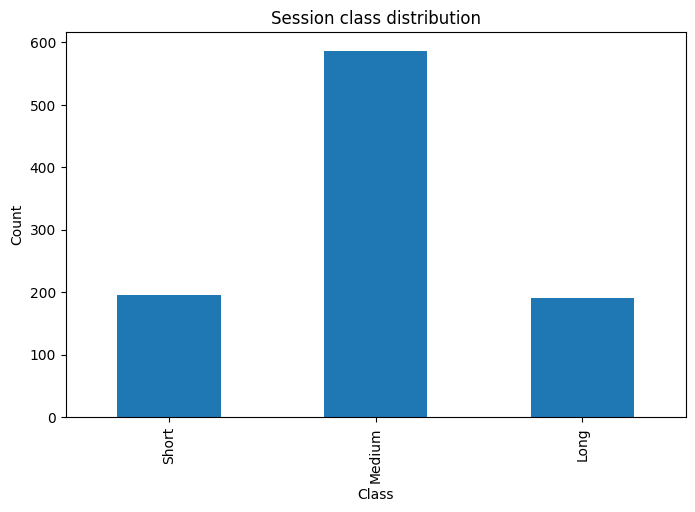

In [5]:

target_regression = "Session_Duration (hours)"

bins = [-np.inf, 1.0, 1.5, np.inf]
labels = ["Short", "Medium", "Long"]

df["Session_Class"] = pd.cut(
    df[target_regression],
    bins=bins,
    labels=labels,
    include_lowest=True
)

ax = df["Session_Class"].value_counts().sort_index().plot(kind="bar", title="Session class distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.show()


In [6]:
# ── Original features ────────────────────────────────────────────────────────
df["HR_Reserve_Ratio"]  = (df["Avg_BPM"] - df["Resting_BPM"]) / (df["Max_BPM"] - df["Resting_BPM"])
df["Intensity_Score"]   = df["Avg_BPM"] * df["Workout_Frequency (days/week)"] / df["BMI"]
df["Cal_per_BPM"]       = df["Calories_Burned"] / df["Avg_BPM"]

# ── NEW: Short-class discriminators ──────────────────────────────────────────
# Short sessions cluster at Experience_Level=1, low Workout_Frequency, low Calories.
# These interaction terms make those patterns explicit so the tree can find clean splits.

# Calories × Experience: Short≈574, Medium≈1522, Long≈3795  (very separable)
df["Cal_x_Experience"]  = df["Calories_Burned"] * df["Experience_Level"]

# Combined activity load: Short≈2.6, Medium≈5.6, Long≈13.6
df["Exp_x_Freq"]        = df["Experience_Level"] * df["Workout_Frequency (days/week)"]

# Calories per weekly session (per-session intensity proxy)
df["Cal_per_Freq"]      = df["Calories_Burned"] / df["Workout_Frequency (days/week)"]

# Fat% × Experience: Short members are mostly beginners with higher fat%
df["FatPct_x_Exp"]      = df["Fat_Percentage"] * df["Experience_Level"]

# Cardiovascular efficiency ratio
df["BPM_Efficiency"]    = df["Resting_BPM"] / df["Avg_BPM"]

print("Feature engineering done. Total columns:", len(df.columns))


Feature engineering done. Total columns: 24


In [7]:

cat_cols = ["Gender", "Workout_Type"]
drop_cols = [target_regression, "Session_Class"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df["Session_Class"].astype(str)

print("Features:", feature_cols)
print("Categorical columns:", cat_cols)


Features: ['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'HR_Reserve_Ratio', 'Intensity_Score', 'Cal_per_BPM', 'Cal_x_Experience', 'Exp_x_Freq', 'Cal_per_Freq', 'FatPct_x_Exp', 'BPM_Efficiency']
Categorical columns: ['Gender', 'Workout_Type']


In [8]:

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (681, 22) (681,)
Validation: (146, 22) (146,)
Test: (146, 22) (146,)


In [9]:
import sys
!{sys.executable} -m pip install imbalanced-learn


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [10]:
# ── Class-Imbalance Handling: SMOTE on training set ──────────────────────────
# Short (195) is ~3× rarer than Medium (587). We oversample Short in the
# training set only so the tree sees a balanced class distribution.
# val/test are never touched — evaluation stays honest.

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

# Encode categoricals temporarily for SMOTE (needs numeric input)
X_train_enc = X_train.copy()
le_map = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train_enc[col] = le.fit_transform(X_train_enc[col].astype(str))
    le_map[col] = le

sm = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = sm.fit_resample(X_train_enc, y_train)

# Decode categoricals back to strings
X_train_res = pd.DataFrame(X_train_res, columns=X_train_enc.columns)
for col in cat_cols:
    X_train_res[col] = le_map[col].inverse_transform(X_train_res[col].round().astype(int))

print("Training class distribution BEFORE SMOTE:")
print(y_train.value_counts())
print("\nTraining class distribution AFTER SMOTE:")
print(pd.Series(y_train_res).value_counts())


Training class distribution BEFORE SMOTE:
Session_Class
Medium    411
Short     136
Long      134
Name: count, dtype: int64

Training class distribution AFTER SMOTE:
Session_Class
Long      411
Medium    411
Short     411
Name: count, dtype: int64


In [11]:
# ── Robust Scaling ────────────────────────────────────────────────────────────
# RobustScaler uses median/IQR so outliers don't pull thresholds away from
# the Short/Medium boundary. The scaler is fit ONLY on the training set.

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
num_cols_scale = [c for c in X_train_res.columns if c not in cat_cols]

X_train_res[num_cols_scale] = scaler.fit_transform(X_train_res[num_cols_scale])

X_val_scaled  = X_val.copy()
X_test_scaled = X_test.copy()
X_val_scaled[num_cols_scale]  = scaler.transform(X_val[num_cols_scale])
X_test_scaled[num_cols_scale] = scaler.transform(X_test[num_cols_scale])

print("Robust scaling applied.")
print("Train shape:", X_train_res.shape, " | Val:", X_val_scaled.shape, " | Test:", X_test_scaled.shape)


Robust scaling applied.
Train shape: (1233, 22)  | Val: (146, 22)  | Test: (146, 22)


## C4.5 implementation from scratch

Main ideas used here:
- **entropy**
- **gain ratio** instead of plain information gain
- support for **categorical** and **continuous** attributes
- simple **reduced-error pruning** using the validation set


In [12]:

def entropy(y):
    values, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()
    return -(p * np.log2(p + 1e-12)).sum()


def gain_ratio_categorical(x_col, y):
    base_entropy = entropy(y)
    total = len(y)

    weighted_entropy = 0.0
    split_info = 0.0

    for value in pd.Series(x_col).unique():
        mask = (x_col == value)
        n = mask.sum()
        if n == 0:
            continue
        p = n / total
        weighted_entropy += p * entropy(y[mask])
        split_info -= p * np.log2(p + 1e-12)

    info_gain = base_entropy - weighted_entropy
    if split_info <= 1e-12:
        return -1, None

    return info_gain / split_info, None


def gain_ratio_numeric(x_col, y, min_samples_leaf=5):
    x = np.asarray(x_col)
    y = np.asarray(y)

    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    candidate_thresholds = []
    for i in range(1, len(x_sorted)):
        if x_sorted[i] != x_sorted[i - 1] and y_sorted[i] != y_sorted[i - 1]:
            candidate_thresholds.append((x_sorted[i] + x_sorted[i - 1]) / 2)

    base_entropy = entropy(y)
    total = len(y)

    best_gain_ratio = -1
    best_threshold = None

    for threshold in candidate_thresholds:
        left_mask = x <= threshold
        right_mask = ~left_mask

        n_left = left_mask.sum()
        n_right = right_mask.sum()

        if n_left < min_samples_leaf or n_right < min_samples_leaf:
            continue

        p_left = n_left / total
        p_right = n_right / total

        weighted_entropy = p_left * entropy(y[left_mask]) + p_right * entropy(y[right_mask])
        info_gain = base_entropy - weighted_entropy

        split_info = 0.0
        for p in [p_left, p_right]:
            split_info -= p * np.log2(p + 1e-12)

        if split_info <= 1e-12:
            continue

        gain_ratio = info_gain / split_info

        if gain_ratio > best_gain_ratio:
            best_gain_ratio = gain_ratio
            best_threshold = threshold

    return best_gain_ratio, best_threshold


@dataclass
class C45Node:
    prediction: Any
    feature: Optional[str] = None
    threshold: Optional[float] = None
    children: dict = field(default_factory=dict)
    is_leaf: bool = True
    depth: int = 0


In [13]:

class C45Classifier:
    def __init__(
        self,
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=8,
        min_gain_ratio=1e-3
    ):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.min_gain_ratio = min_gain_ratio

    def fit(self, X, y, categorical_features=None):
        self.features_ = list(X.columns)
        self.categorical_features_ = set(
            categorical_features or X.select_dtypes(include=["object", "category"]).columns.tolist()
        )
        self.classes_ = np.unique(y)
        self.root_ = self._build_tree(
            X.reset_index(drop=True),
            pd.Series(y).reset_index(drop=True),
            depth=0
        )
        return self

    def _majority_class(self, y):
        return y.value_counts().idxmax()

    def _best_split(self, X, y):
        best = {
            "gain_ratio": -1,
            "feature": None,
            "threshold": None
        }

        for col in X.columns:
            if col in self.categorical_features_:
                gr, threshold = gain_ratio_categorical(X[col].to_numpy(), y.to_numpy())
            else:
                gr, threshold = gain_ratio_numeric(
                    X[col].to_numpy(),
                    y.to_numpy(),
                    min_samples_leaf=self.min_samples_leaf
                )

            if gr > best["gain_ratio"]:
                best["gain_ratio"] = gr
                best["feature"] = col
                best["threshold"] = threshold

        return best

    def _build_tree(self, X, y, depth):
        node = C45Node(
            prediction=self._majority_class(y),
            depth=depth
        )

        if len(y.unique()) == 1:
            return node

        if len(y) < self.min_samples_split:
            return node

        if depth >= self.max_depth:
            return node

        split = self._best_split(X, y)

        if split["feature"] is None or split["gain_ratio"] < self.min_gain_ratio:
            return node

        feature = split["feature"]
        threshold = split["threshold"]

        node.feature = feature
        node.threshold = threshold
        node.is_leaf = False

        if feature in self.categorical_features_:
            for value in X[feature].unique():
                mask = X[feature] == value

                if mask.sum() < self.min_samples_leaf:
                    continue

                child_X = X.loc[mask].drop(columns=[feature]).reset_index(drop=True)
                child_y = y.loc[mask].reset_index(drop=True)

                node.children[value] = self._build_tree(child_X, child_y, depth + 1)

            if len(node.children) == 0:
                node.is_leaf = True
                node.feature = None
                node.threshold = None

        else:
            left_mask = X[feature] <= threshold
            right_mask = ~left_mask

            if left_mask.sum() < self.min_samples_leaf or right_mask.sum() < self.min_samples_leaf:
                node.is_leaf = True
                node.feature = None
                node.threshold = None
                return node

            node.children["<="] = self._build_tree(
                X.loc[left_mask].reset_index(drop=True),
                y.loc[left_mask].reset_index(drop=True),
                depth + 1
            )
            node.children[">"] = self._build_tree(
                X.loc[right_mask].reset_index(drop=True),
                y.loc[right_mask].reset_index(drop=True),
                depth + 1
            )

        return node

    def _predict_one(self, row, node):
        current = node

        while not current.is_leaf:
            if current.feature in self.categorical_features_:
                value = row[current.feature]
                if value in current.children:
                    current = current.children[value]
                else:
                    break
            else:
                if row[current.feature] <= current.threshold:
                    current = current.children["<="]
                else:
                    current = current.children[">"]

        return current.prediction

    def predict(self, X):
        return np.array([self._predict_one(row, self.root_) for _, row in X.iterrows()])

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))

    def count_nodes(self):
        def _count(node):
            if node.is_leaf:
                return 1
            return 1 + sum(_count(child) for child in node.children.values())
        return _count(self.root_)

    def prune(self, X_val, y_val):
        X_val = X_val.reset_index(drop=True)
        y_val = pd.Series(y_val).reset_index(drop=True)
        self._prune_node(self.root_, X_val, y_val)
        return self

    def _prune_node(self, node, X_val, y_val):
        if node.is_leaf or len(X_val) == 0:
            return

        if node.feature in self.categorical_features_:
            for value, child in list(node.children.items()):
                mask = X_val[node.feature] == value
                self._prune_node(child, X_val.loc[mask], y_val.loc[mask])
        else:
            left_mask = X_val[node.feature] <= node.threshold
            self._prune_node(node.children["<="], X_val.loc[left_mask], y_val.loc[left_mask])
            self._prune_node(node.children[">"], X_val.loc[~left_mask], y_val.loc[~left_mask])

        if len(X_val) == 0:
            return

        pred_before = np.array([self._predict_one(row, node) for _, row in X_val.iterrows()])
        acc_before = accuracy_score(y_val, pred_before)

        backup = (node.is_leaf, node.feature, node.threshold, node.children)

        node.is_leaf = True
        node.feature = None
        node.threshold = None
        node.children = {}

        pred_after = np.array([node.prediction] * len(y_val))
        acc_after = accuracy_score(y_val, pred_after)

        if acc_after < acc_before:
            node.is_leaf, node.feature, node.threshold, node.children = backup


In [14]:
c45 = C45Classifier(
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=8,
    min_gain_ratio=1e-3
)

c45.fit(X_train_res, y_train_res, categorical_features=cat_cols)

print("Nodes before pruning:", c45.count_nodes())
print("Train accuracy:", round(c45.score(X_train_res, y_train_res), 4))
print("Validation accuracy:", round(c45.score(X_val_scaled, y_val), 4))
print("Test accuracy before pruning:", round(c45.score(X_test_scaled, y_test), 4))


Nodes before pruning: 29
Train accuracy: 0.9854
Validation accuracy: 0.9589
Test accuracy before pruning: 0.9589


In [15]:
c45.prune(X_val_scaled, y_val)

print("Nodes after pruning:", c45.count_nodes())
print("Train accuracy after pruning:", round(c45.score(X_train_res, y_train_res), 4))
print("Validation accuracy after pruning:", round(c45.score(X_val_scaled, y_val), 4))
print("Test accuracy after pruning:", round(c45.score(X_test_scaled, y_test), 4))


Nodes after pruning: 7
Train accuracy after pruning: 0.9781
Validation accuracy after pruning: 0.9726
Test accuracy after pruning: 0.9726


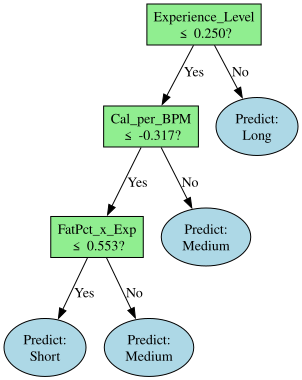

In [16]:

from graphviz import Digraph

def visualize_tree(node, dot=None, node_id=None):
    """
    Create a graphical visualization of the C4.5 tree using Graphviz.
    """
    if dot is None:
        dot = Digraph(comment='C45 Decision Tree')
        dot.attr(rankdir='TB')
        dot.attr('node', shape='box', style='rounded')
        node_id = [0]  # Use list to maintain state across recursion
    
    current_id = node_id[0]
    
    if node.is_leaf:
        label = f"Predict:\n{node.prediction}"
        dot.node(str(current_id), label, shape='ellipse', style='filled', fillcolor='lightblue')
        node_id[0] += 1
    else:
        if node.threshold is not None:
            # Continuous feature
            label = f"{node.feature}\n≤ {node.threshold:.3f}?"
        else:
            # Categorical feature
            label = f"{node.feature}"
        
        dot.node(str(current_id), label, shape='box', style='filled', fillcolor='lightgreen')
        parent_id = current_id
        node_id[0] += 1
        
        # Add children
        for child_key, child_node in sorted(node.children.items()):
            child_start_id = node_id[0]
            visualize_tree(child_node, dot, node_id)
            
            # Edge label
            if node.threshold is not None:
                edge_label = "Yes" if child_key == "<=" else "No"
            else:
                edge_label = str(child_key)
            
            dot.edge(str(parent_id), str(child_start_id), label=edge_label)
    
    return dot


# Create and display the tree
tree_viz = visualize_tree(c45.root_)
from IPython.display import SVG
svg_content = tree_viz.pipe(format='svg').decode('utf-8')
SVG(svg_content)



In [17]:
y_pred = c45.predict(X_test_scaled)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.9726

Classification report:
              precision    recall  f1-score   support

        Long       1.00      1.00      1.00        29
      Medium       0.98      0.98      0.98        88
       Short       0.93      0.93      0.93        29

    accuracy                           0.97       146
   macro avg       0.97      0.97      0.97       146
weighted avg       0.97      0.97      0.97       146



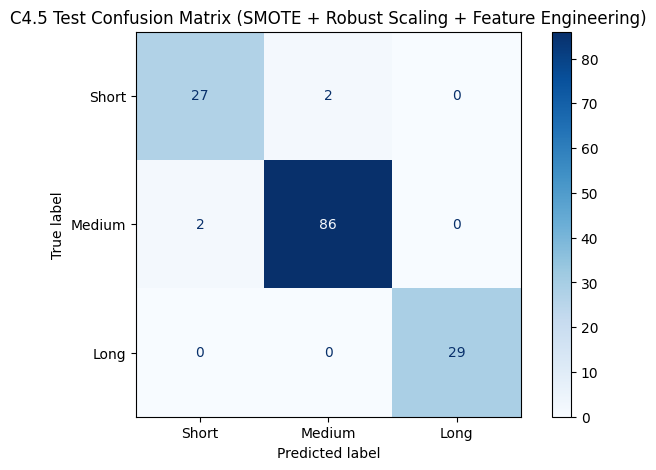

In [18]:
cm = confusion_matrix(y_test, y_pred, labels=["Short", "Medium", "Long"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Short", "Medium", "Long"])
disp.plot(cmap="Blues")
plt.title("C4.5 Test Confusion Matrix (SMOTE + Robust Scaling + Feature Engineering)")
plt.show()


## Tree printing helper

This gives you a readable rule-based representation, similar to the way decision-tree logic is usually explained in class.


In [19]:

def print_tree(node, indent=""):
    if node.is_leaf:
        print(indent + "Predict -> " + str(node.prediction))
        return

    if node.threshold is not None:
        print(indent + f"[{node.feature} <= {node.threshold:.4f}]")
        print(indent + "  Yes:")
        print_tree(node.children["<="], indent + "    ")
        print(indent + "  No:")
        print_tree(node.children[">"], indent + "    ")
    else:
        for value, child in node.children.items():
            print(indent + f"[{node.feature} == {value}]")
            print_tree(child, indent + "    ")

print_tree(c45.root_)


[Experience_Level <= 0.2500]
  Yes:
    [Cal_per_BPM <= -0.3169]
      Yes:
        [FatPct_x_Exp <= 0.5529]
          Yes:
            Predict -> Short
          No:
            Predict -> Medium
      No:
        Predict -> Medium
  No:
    Predict -> Long


In [20]:

sample = X_test.iloc[[0]].copy()
sample


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Calories_Burned,Workout_Type,Fat_Percentage,...,Experience_Level,BMI,HR_Reserve_Ratio,Intensity_Score,Cal_per_BPM,Cal_x_Experience,Exp_x_Freq,Cal_per_Freq,FatPct_x_Exp,BPM_Efficiency
416,31,Male,78.8,1.71,177,121,59,992.0,HIIT,24.7,...,2,26.95,0.525424,17.959184,8.198347,1984.0,8,248.0,49.4,0.487603


In [21]:

sample_pred = c45.predict(sample)[0]
true_class = y_test.iloc[0]

print("Predicted class:", sample_pred)
print("True class:", true_class)


Predicted class: Long
True class: Medium


## Optional experiment section

You can tune these values exactly like you did in your Iterative Dichotomiser work:
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `min_gain_ratio`

Try changing them and compare validation accuracy before deciding on the final model.


In [22]:
results = []

for depth in [4, 6, 8, 10]:
    for min_leaf in [4, 8, 12]:
        trial = C45Classifier(
            max_depth=depth,
            min_samples_split=20,
            min_samples_leaf=min_leaf,
            min_gain_ratio=1e-3
        )
        trial.fit(X_train_res, y_train_res, categorical_features=cat_cols)
        trial.prune(X_val_scaled, y_val)

        results.append({
            "max_depth": depth,
            "min_samples_leaf": min_leaf,
            "train_acc": trial.score(X_train_res, y_train_res),
            "val_acc": trial.score(X_val_scaled, y_val),
            "test_acc": trial.score(X_test_scaled, y_test),
            "nodes": trial.count_nodes()
        })

results_df = pd.DataFrame(results)
results_df["val_f1"] = f1_score(y_val, trial.predict(X_val_scaled), average="macro")
results_df.sort_values(by="val_f1", ascending=False)


,max_depth,min_samples_leaf,train_acc,val_acc,test_acc,nodes,val_f1
0,4,4,0.978102,0.972603,0.972603,7,0.969521
1,4,8,0.978102,0.972603,0.972603,7,0.969521
2,4,12,0.978102,0.972603,0.972603,7,0.969521
3,6,4,0.978102,0.972603,0.972603,7,0.969521
4,6,8,0.978102,0.972603,0.972603,7,0.969521
5,6,12,0.978102,0.972603,0.972603,7,0.969521
6,8,4,0.978102,0.972603,0.972603,7,0.969521
7,8,8,0.978102,0.972603,0.972603,7,0.969521
8,8,12,0.978102,0.972603,0.972603,7,0.969521
9,10,4,0.978102,0.972603,0.972603,7,0.969521


In [23]:
# Extended hyperparameter tuning and diagnostics
from sklearn.model_selection import ParameterGrid

param_grid = {
    "max_depth": [12, 15, 20],
    "min_samples_split": [2, 4, 6],
    "min_samples_leaf": [4, 8, 12],
    "min_gain_ratio": [1e-5, 1e-4, 5e-4],
}

results = []
for params in ParameterGrid(param_grid):
    model = C45Classifier(
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"],
        min_gain_ratio=params["min_gain_ratio"],
    )
    model.fit(X_train_res, y_train_res, categorical_features=cat_cols)
    model.prune(X_val_scaled, y_val)

    results.append({
        **params,
        "train_acc": model.score(X_train_res, y_train_res),
        "val_acc": model.score(X_val_scaled, y_val),
        "test_acc": model.score(X_test_scaled, y_test),
        "nodes": model.count_nodes(),
    })

results_df = pd.DataFrame(results).sort_values(
    by=["val_acc", "test_acc", "nodes"], ascending=[False, False, True]
)
results_df.head(10)

best_params = results_df.iloc[0][["max_depth", "min_samples_split", "min_samples_leaf", "min_gain_ratio"]].to_dict()
print("Best params based on validation accuracy:", best_params)
print("Best validation accuracy:", round(results_df.iloc[0]["val_acc"], 4))
print("Corresponding test accuracy:", round(results_df.iloc[0]["test_acc"], 4))

# Compare best model before and after pruning
best_model = C45Classifier(**best_params)
best_model.fit(X_train_res, y_train_res, categorical_features=cat_cols)
pre_prune_val  = best_model.score(X_val_scaled, y_val)
pre_prune_test = best_model.score(X_test_scaled, y_test)
best_model.prune(X_val_scaled, y_val)
post_prune_val  = best_model.score(X_val_scaled, y_val)
post_prune_test = best_model.score(X_test_scaled, y_test)

print("\nBest model before pruning -> Val:", round(pre_prune_val, 4), "Test:", round(pre_prune_test, 4))
print("Best model after pruning  -> Val:", round(post_prune_val, 4), "Test:", round(post_prune_test, 4))

# Feature usage diagnostic
def feature_usage(node):
    if node.is_leaf:
        return {}
    counts = {node.feature: 1}
    for child in node.children.values():
        child_counts = feature_usage(child)
        for feature, count in child_counts.items():
            counts[feature] = counts.get(feature, 0) + count
    return counts

usage = feature_usage(best_model.root_)
usage_df = pd.DataFrame(
    sorted(usage.items(), key=lambda x: x[1], reverse=True),
    columns=["feature", "usage_count"],
)
print("\nFeature usage in the best pruned tree:")
print(usage_df)


Best params based on validation accuracy: {'max_depth': 12.0, 'min_samples_split': 2.0, 'min_samples_leaf': 4.0, 'min_gain_ratio': 1e-05}
Best validation accuracy: 0.9726
Corresponding test accuracy: 0.9726

Best model before pruning -> Val: 0.9589 Test: 0.9589
Best model after pruning  -> Val: 0.9726 Test: 0.9726

Feature usage in the best pruned tree:
            feature  usage_count
0  Experience_Level            1
1       Cal_per_BPM            1
2      FatPct_x_Exp            1


## Final note

If your professor wants the notebook to stay even closer to ID3 terminology, you can present this as:

- **ID3** -> categorical splits, information gain
- **C4.5** -> continuous features, gain ratio, pruning

This notebook already includes those C4.5-style improvements.


In [24]:
X_tv = pd.concat([X_train_res, X_val_scaled])
y_tv = pd.concat([pd.Series(y_train_res), y_val])
final = C45Classifier(**best_params)
final.fit(X_tv, y_tv, categorical_features=cat_cols)
# No pruning — params already tuned on val set
print(classification_report(y_test, final.predict(X_test_scaled)))


              precision    recall  f1-score   support

        Long       1.00      1.00      1.00        29
      Medium       0.98      0.97      0.97        88
       Short       0.90      0.93      0.92        29

    accuracy                           0.97       146
   macro avg       0.96      0.97      0.96       146
weighted avg       0.97      0.97      0.97       146

